# Eye-Tracking Metric Extraction (`precision_saccade_smooth_fixation`)

### Overview
This notebook computes Root Mean Square (RMS) precision errors to quantify eye-tracker accuracy across distinct gaze behaviors.

### Metrics Computed
* **`precision_saccade`**: Precision during rapid, discrete eye movements (Calibration task).
* **`precision_smooth`**: Precision during continuous object tracking (W1 Smooth Pursuit task).
* **`precision_fixate`**: Baseline precision during static fixations, tracked across both task environments.

### Analysis Pipeline
* **Aggregation**: Loops through raw participant data to compute behavioral RMS errors per Inter-Stimulus Interval (ISI).
* **I/O Optimization**: Appends metrics to local data structures before writing consolidated datasets to disk to eliminate disk I/O bottlenecks.


In [1]:
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

current_dir = pathlib.Path(os.getcwd())
sys.path.append(str(current_dir.parent))

from python_scripts.util import *

target_type = 'moving' # Valid types = [moving, static]
calibrate_with = 'cal' # choices=['cal', 'w1', 'w2', 'w3', 's4', 'b5']
FS = 60 # 60Hz sampling rate means ~16.67ms per frame

In [2]:
# Setup directories
recalibrated_data_dir = get_recalibrated_data_dir(target_type, calibrate_with)
raw_data_dir = get_raw_data_directory()

error_df_path = os.path.join(recalibrated_data_dir, 'error_df.csv')
precision_saccade_df_path = 'csv/precision_saccade_df.csv'
precision_smooth_df_path = 'csv/precision_smooth_df.csv'

# Ensure that the recalibrated dataset exists for all participants before computing error plots
%run ../python_scripts/recalibrate_data.py --type {target_type} --with {calibrate_with}

error_df = pd.read_csv(error_df_path)
precision_saccade_df = pd.read_csv(precision_saccade_df_path) if os.path.exists(precision_saccade_df_path) else pd.DataFrame(columns=['Name','ISI', 'precision_saccade', 'precision_fixate']) 
precision_smooth_df = pd.read_csv(precision_smooth_df_path) if os.path.exists(precision_smooth_df_path) else pd.DataFrame(columns=['Name','ISI', 'precision_smooth', 'precision_fixate']) 

Starting execution. Total participants to process: 36


Overall Progress: 100%|██████████| 36/36 [00:00<?, ?participant/s]


Script execution completed successfully!


In [3]:
participants_and_tasks = []
participant_names = get_all_participants()

# Loop through participants
for participant in participant_names:
    tasks_file_dir = get_participant_raw_files(participant)
    if tasks_file_dir.get("cal") and tasks_file_dir.get("w1"):
        participants_and_tasks.append([participant, tasks_file_dir.get("cal"), tasks_file_dir.get("w1")])


In [4]:


while participants_and_tasks:
    participant, cal_task_csv, w1_task_csv = participants_and_tasks.pop(0)
    
    if error_df.loc[error_df['Name'] == participant].callibrate_vec.astype(float).item()>2.5:            
        print(f"\nSkipping '{participant}' since error is too high, likely an outlier.")
        continue

    for current_task_csv in [cal_task_csv, w1_task_csv]:
        # Using the calibration task for saccadic/fixations
        if (participant in precision_saccade_df['Name'].values and current_task_csv == cal_task_csv) or \
          (participant in precision_smooth_df['Name'].values and current_task_csv == w1_task_csv):
            continue

        df = pd.read_csv(current_task_csv, index_col=False)  

        # Handle edge case: Skip empty files or files with insufficient data
        if len(df) < 2:
            print(f"Skipping {participant}: Not enough rows.")
            continue

        rms_error_saccadic = 0
        rms_error_fixation = 0
        rms_error_smooth = 0

        count_saccadic = 0
        count_fixate = 0
        count_smooth = 0
        isi = 0 # Inter-Sample Interval

        # Reset index ensures 'index - 1' is always mathematically safe and sequential
        df_clean = clean_df(df.reset_index(drop=True), remove_static=True)

        # Index boundaries for the dynamic saccade window
        next_saccade_idx_start = -1
        next_saccade_idx_end = -1
        
        # Loop sequentially across frames using numeric indices
        for index in range(1, len(df_clean)):
            row = df_clean.iloc[index]
            prev_row = df_clean.iloc[index - 1]
            isi += row["seconds"] - prev_row["seconds"]
            
            # 1. Detect Stimulus Jump using target 2D screen positions
            p_target = [prev_row['target_vis_x'], prev_row['target_vis_y']]
            q_target = [row['target_vis_x'], row['target_vis_y']]
            
            if (math.dist(p_target, q_target) > 0.1 and current_task_csv == cal_task_csv) or \
                (prev_row['PathIDX'] <0 and row['PathIDX'] >0 and row['PathIDX'] > 0 and current_task_csv == w1_task_csv):
                # Saccadic eye movements occur when the screen-stabilized stimulus changes position. 
                # A single saccade typically lasts between 20 to 200 ms, with an onset latency of ~200 ms. 
                # Reference: Purves, D., et al. (2001). Types of Eye Movements and Their Functions. Neuroscience. 2nd edition.
                # The minimum distance between any two stimulus positions in our calibration task is 0.25 units, we consider 0.1 as the threshold. 
                # For W1 task, the target starts moving (row['PathIDX'] > 0) after a rest (row['PathIDX'] <0), which can lead to saccadic motion.
                next_saccade_idx_start = index + int(FS * 0.180)  # ~11 frames later
                next_saccade_idx_end = next_saccade_idx_start + int(FS * 0.100)  # ~6 frames duration

            # 2. Blink and Confidence Validation Gate
            # Skip calculation if the current frame or the baseline comparison frame contains a blink
            if row['left_right_eye_is_blinking'] or prev_row['left_right_eye_is_blinking']:
                continue

            # Extract consecutive gaze visual coordinates for precision calculation
            p_gaze = [prev_row['gaze_vis_x'], prev_row['gaze_vis_y']]
            q_gaze = [row['gaze_vis_x'], row['gaze_vis_y']]
            spatial_displacement_sq = math.dist(p_gaze, q_gaze) ** 2
            # print(f"\n {spatial_displacement_sq} {current_task != w1_task_csv}")

            # 3. Check Saccadic Window 
            if next_saccade_idx_start <= index <= next_saccade_idx_end:
                rms_error_saccadic += spatial_displacement_sq
                count_saccadic += 1
                    
            # 4. Check Fixation and Smooth Pursuit Window (Outside active saccade timelines)
            elif index>next_saccade_idx_end:
                if current_task_csv == w1_task_csv:
                    if row['PathIDX']>0 and row['PathIDX']!=99: 
                        rms_error_smooth += spatial_displacement_sq
                        count_smooth += 1
                    else: # Both 99 and <0 are when the stimulus is stopped (fixation)
                        rms_error_fixation += spatial_displacement_sq
                        count_fixate += 1
                elif current_task_csv == cal_task_csv:
                    rms_error_fixation += spatial_displacement_sq
                    count_fixate += 1

        # Finalize Root Mean Square (RMS) calculation for Precision
        rms_error_saccadic = math.sqrt(rms_error_saccadic / count_saccadic) if count_saccadic > 0 else 0.0
        rms_error_fixation = math.sqrt(rms_error_fixation / count_fixate) if count_fixate > 0 else 0.0
        rms_error_smooth = math.sqrt(rms_error_smooth/count_smooth) if count_smooth > 0 else 0.0
        isi /= len(df_clean) - 1 
        
        if current_task_csv == cal_task_csv:
            precision_saccade_df.loc[len(precision_saccade_df.index)] = [participant, isi, rms_error_saccadic, rms_error_fixation] 
            precision_saccade_df.to_csv(precision_saccade_df_path, index= False)
        elif current_task_csv == w1_task_csv:
            precision_smooth_df.loc[len(precision_smooth_df.index)] = [participant, isi, rms_error_smooth, rms_error_fixation] 
            precision_smooth_df.to_csv(precision_smooth_df_path, index= False)


Skipping 'participant-012' since error is too high, likely an outlier.

Skipping 'participant-013' since error is too high, likely an outlier.

Skipping 'participant-026' since error is too high, likely an outlier.

Skipping 'participant-032' since error is too high, likely an outlier.

Skipping 'participant-035' since error is too high, likely an outlier.


In [ ]:
import scipy
from scipy.stats.mstats import winsorize


precision_saccade_df = pd.read_csv(precision_saccade_df_path, index_col=False)
precision_smooth_df = pd.read_csv(precision_smooth_df_path, index_col=False)

def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

# Convert ISI from seconds to milliseconds
precision_saccade_df['ISI'] = precision_saccade_df['ISI'].apply(lambda p: p * 1000)

# Corrected Winsorization syntax (assigning back directly to columns)
precision_smooth_df['precision_smooth'] = winsorize(precision_smooth_df['precision_smooth'], limits=(0.2, 0.2))
precision_smooth_df['precision_fixate'] = winsorize(precision_smooth_df['precision_fixate'], limits=(0.2, 0.2))
precision_saccade_df['precision_fixate'] = winsorize(precision_saccade_df['precision_fixate'], limits=(0.2, 0.2))
precision_saccade_df['precision_saccade'] = winsorize(precision_saccade_df['precision_saccade'], limits=(0.2, 0.2))

# Calculate Confidence Intervals
isi = mean_confidence_interval(precision_saccade_df['ISI'])
precision_smooth = mean_confidence_interval(precision_smooth_df['precision_smooth'])
precision_fixate_smooth = mean_confidence_interval(precision_smooth_df['precision_fixate'])
precision_saccade = mean_confidence_interval(precision_saccade_df['precision_saccade'])
precision_fixate_saccade = mean_confidence_interval(precision_saccade_df['precision_fixate'])

# Combine lists for the overall metric
overall_list = pd.concat([
    precision_smooth_df['precision_smooth'],
    precision_smooth_df['precision_fixate'],
    precision_saccade_df['precision_saccade']
], axis=0)
overall = mean_confidence_interval(overall_list)

# Print formatted output tuples (Mean, Lower CI, Upper CI)
print('ISI: (' + ', '.join(('%.4f' % f) for f in isi) + ')')
print('Smooth: (' + ', '.join(('%.4f' % f) for f in precision_smooth) + ')')
print('Fixate (Smooth Task): (' + ', '.join(('%.4f' % f) for f in precision_fixate_smooth) + ')')
print('Saccade: (' + ', '.join(('%.4f' % f) for f in precision_saccade) + ')')
print('Fixate (Saccade Task): (' + ', '.join(('%.4f' % f) for f in precision_fixate_saccade) + ')')
print('Overall: (' + ', '.join(('%.4f' % f) for f in overall) + ')')


ISI: (16.6850, 16.5569, 16.8131)
Smooth: (0.4621, 0.4011, 0.5231)
Fixate (Smooth Task): (0.6096, 0.5318, 0.6873)
Saccade: (1.9799, 1.6892, 2.2706)
Fixate (Saccade Task): (1.3316, 1.2639, 1.3994)
Overall: (1.0172, 0.8448, 1.1896)


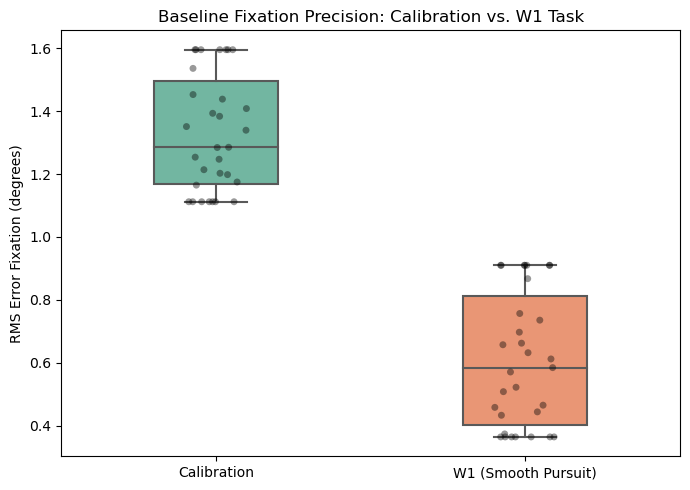

c:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3806: UserWarning: Setting `sharex=False` with `color=None` may cause different levels of the `x` variable to share colors. This will change in a future version.
  warnings.warn(msg.format("sharex", "x"), UserWarning)


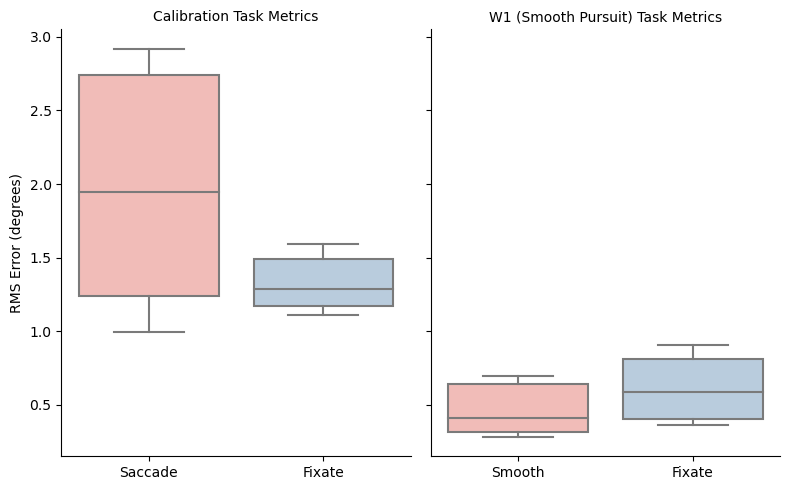

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data and ensure standard column names
# (Assuming columns: ['participant', 'isi', 'rms_error_saccadic', 'rms_error_fixation'] etc.)
cal_df = precision_saccade_df.copy()
w1_df = precision_smooth_df.copy()

# 2. Extract baseline fixation error from both tasks to compare them side-by-side
cal_df['Task'] = 'Calibration'
w1_df['Task'] = 'W1 (Smooth Pursuit)'

# 3. Combine both tasks into one dataset
combined_df = pd.concat([
    cal_df[['Name', 'ISI', 'precision_fixate', 'Task']],
    w1_df[['Name', 'ISI', 'precision_fixate', 'Task']]
], ignore_index=True)

plt.figure(figsize=(7, 5))

# Plot using exact column headers
sns.boxplot(data=combined_df, x='Task', y='precision_fixate', palette='Set2', width=0.4)
sns.stripplot(data=combined_df, x='Task', y='precision_fixate', color='black', alpha=0.4, jitter=0.1)

plt.title('Baseline Fixation Precision: Calibration vs. W1 Task')
plt.ylabel('RMS Error Fixation (degrees)')
plt.xlabel('')
plt.tight_layout()
plt.show()

# Melt calibration data
cal_long = cal_df.melt(
    id_vars=['Task'], 
    value_vars=['precision_saccade', 'precision_fixate'],
    var_name='Metric', value_name='RMS_Error'
)

# Melt W1 data
w1_long = w1_df.melt(
    id_vars=['Task'], 
    value_vars=['precision_smooth', 'precision_fixate'],
    var_name='Metric', value_name='RMS_Error'
)

# Merge everything for a clean facet plot
all_metrics_df = pd.concat([cal_long, w1_long], ignore_index=True)
all_metrics_df['Metric'] = all_metrics_df['Metric'].str.replace('precision_', '').str.title()

# Plot the comparison panels
g = sns.catplot(
    data=all_metrics_df, 
    x='Metric', 
    y='RMS_Error', 
    col='Task', 
    kind='box', 
    palette='Pastel1',
    sharex=False,
    height=5, 
    aspect=0.8,
)

g.set_axis_labels("", "RMS Error (degrees)")
g.set_titles("{col_name} Task Metrics")
plt.tight_layout()
plt.show()